In [9]:
import math
import torch
import sys
from pathlib import Path

d2l_dir = Path(r"C:\Users\abc\Documents\GitHub\vscodepractice\deeplearning")
sys.path.insert(0, str(d2l_dir / "vendor"))

from d2l import torch as d2l
from torch import nn

In [10]:
num_hiddens, num_heads = 100, 5
attention = d2l.MultiHeadAttention(num_hiddens, num_heads, 0.5)
batch_size, num_queries, valid_lens = 2, 4, torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
d2l.check_shape(attention(X, X, X, valid_lens),
                (batch_size, num_queries, num_hiddens))

In [11]:
class PositionalEncoding(nn.Module):
    """使用正弦和余弦为序列中的每个位置生成编码。"""

    def __init__(self, num_hiddens, dropout, max_len=1000):
        super().__init__()

        self.dropout = nn.Dropout(dropout)

        # P 的形状为 (1, max_len, num_hiddens)：
        # 1             表示之后可以自动扩展到不同的 batch
        # max_len       表示最多支持多少个位置
        # num_hiddens   表示每个位置编码有多少个特征
        self.P = torch.zeros((1, max_len, num_hiddens))

        # position 的形状为 (max_len, 1)。
        # 例如 position 中依次保存 0, 1, 2, ..., max_len - 1。
        position = torch.arange(max_len, dtype=torch.float32).reshape(-1, 1)

        # dimension_index 保存偶数维度对应的下标：0, 2, 4, ...。
        dimension_index = torch.arange(
            0, num_hiddens, 2, dtype=torch.float32
        )

        # 计算不同维度对应的缩放因子。
        # 每一列对应一个偶数维度，每一行对应一个位置。
        angle_rates = torch.pow(10000, dimension_index / num_hiddens)

        # position / angle_rates 的形状为 (max_len, num_hiddens / 2)。
        position_angles = position / angle_rates

        # 偶数维度使用 sin，奇数维度使用 cos。
        self.P[:, :, 0::2] = torch.sin(position_angles) # 0::2的意思是从0开始，每隔2个取一个元素，即取偶数索引的元素。
        self.P[:, :, 1::2] = torch.cos(position_angles) # 1::2的意思是从1开始，每隔2个取一个元素，即取奇数索引的元素。

    def forward(self, X):
        # 只取和当前序列长度一样长的位置编码。
        sequence_length = X.shape[1]
        position_encoding = self.P[:, :sequence_length, :].to(X.device)

        # 将词向量和对应位置的位置编码相加。
        X = X + position_encoding
        return self.dropout(X)

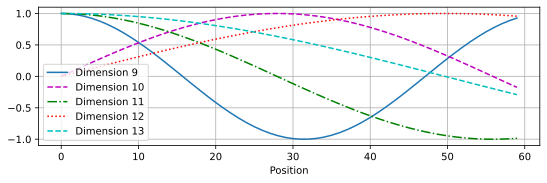

In [14]:
encoding_dimension = 32
number_of_positions = 60

positional_encoding = PositionalEncoding(
    num_hiddens=encoding_dimension,
    dropout=0
)

# 输入全零向量，观察加入位置编码之后的结果。
zero_embeddings = torch.zeros(
    (1, number_of_positions, encoding_dimension)
)
encoded_zeros = positional_encoding(zero_embeddings)

# 取出前 number_of_positions 个位置的编码。
position_encoding_values = positional_encoding.P[:, :number_of_positions, :]

# 观察第 9 到第 13 个特征维度随位置的变化。
selected_dimensions = position_encoding_values[0, :, 9:14].T
position_indices = torch.arange(number_of_positions)

legend_labels = [
    f"Dimension {dimension}"
    for dimension in range(9, 14)
]

# d2l.plot 默认只有 4 种线型，因此为 5 条曲线显式提供 5 种线型。
line_formats = ("-", "m--", "g-.", "r:", "c--")

d2l.plot(
    position_indices,
    selected_dimensions,
    xlabel="Position",
    figsize=(9, 2.5),
    legend=legend_labels,
    fmts=line_formats
)

In [15]:
for i in range(8):
    print(f'{i} in binary is {i:>03b}')

0 in binary is 000
1 in binary is 001
2 in binary is 010
3 in binary is 011
4 in binary is 100
5 in binary is 101
6 in binary is 110
7 in binary is 111


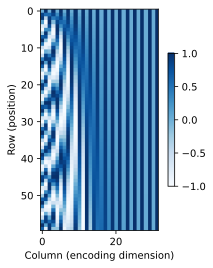

In [16]:
P = P[0, :, :].unsqueeze(0).unsqueeze(0)
d2l.show_heatmaps(P, xlabel='Column (encoding dimension)',
                  ylabel='Row (position)', figsize=(3.5, 4), cmap='Blues')